Memulai perhitungan untuk LQR...
Menghitung turunan simbolik G...
Turunan simbolik G telah di-lambdify.
Matriks M_eq:
[[ 2.70835494 -2.20523897]
 [-2.20523897  5.32278425]]
Matriks dG_dq_eq:
[[  4.90233973  -4.10193837]
 [ -4.10193837 -45.35399156]]

Matriks A linearisasi:
[[ 0.          1.          0.          0.        ]
 [-1.78462292  0.         12.75528831  0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.03126528  0.         13.80526562  0.        ]]

Matriks B linearisasi:
[[0.         0.        ]
 [0.55718982 0.23084473]
 [0.         0.        ]
 [0.23084473 0.28351098]]

Nilai Eigen dari matriks A linearisasi: [ 2.77555756e-17+1.34542247j  2.77555756e-17-1.34542247j
 -3.71897893e+00+0.j          3.71897893e+00+0.j        ]
Sistem linearisasi tidak stabil (memiliki nilai eigen dengan bagian riil positif).

Matriks Q:
[[10  0  0  0]
 [ 0  1  0  0]
 [ 0  0 10  0]
 [ 0  0  0  1]]

Matriks R:
[[0.1 0. ]
 [0.  0.1]]

Matriks P (solusi ARE):
[[  7.20728885   1.76676

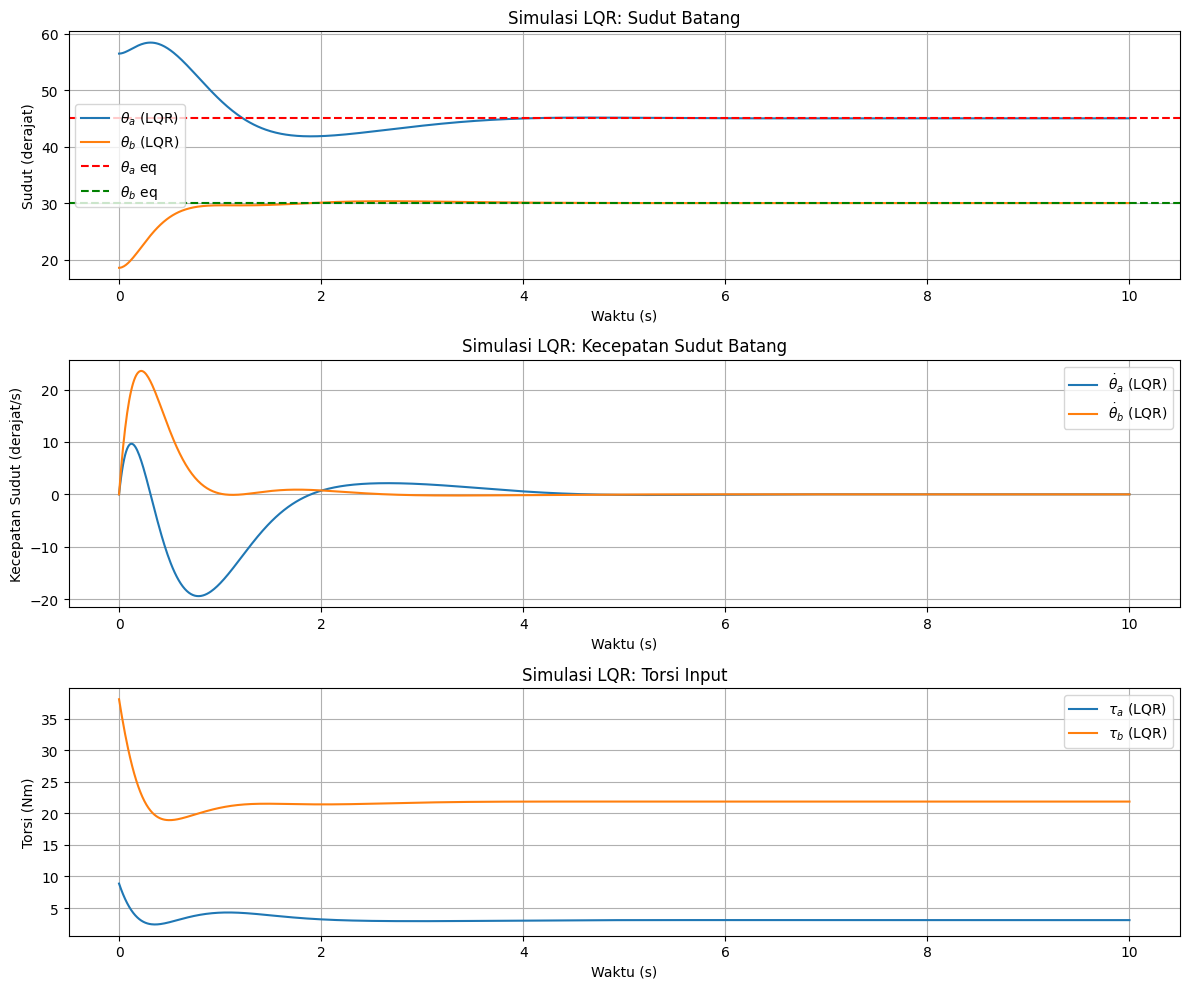


Simulasi LQR selesai.

Memulai simulasi Open-Loop dari kondisi awal: [0.9853981633974482, 0.0, 0.3235987755982988, 0.0] untuk perbandingan...


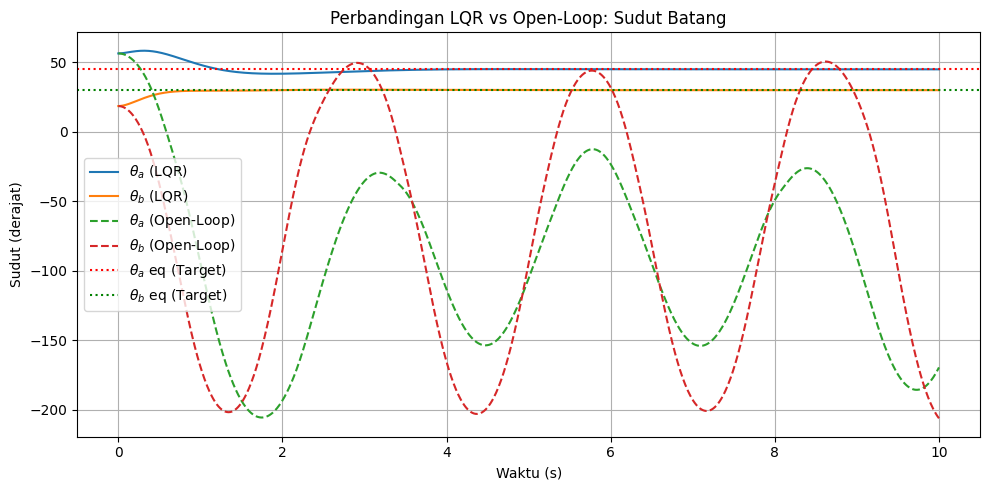

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.linalg import solve_continuous_are
import sympy as sp

# ==============================================================================
# Definisi Simbolik dan Model Nonlinier
# ==============================================================================

# Parameter sistem
m_C = m_D = 1.2  # massa batang (kg)
m_E = 0.75     # massa end effector (kg)
g = 9.81       # gravitasi
Lb_val = 1.1   # panjang batang
Bx_val = 2 * Lb_val # Bx_val = 2.2

# Kondisi awal (digunakan juga sebagai titik ekuilibrium untuk linearisasi)
theta_a_eq = np.pi / 4  # sudut ekuilibrium theta_a (rad)
theta_b_eq = np.pi / 6  # sudut ekuilibrium theta_b (rad)
dtheta_a_eq = 0.0       # kecepatan ekuilibrium theta_a
dtheta_b_eq = 0.0       # kecepatan ekuilibrium theta_b

# Simbol
theta_a_sym, theta_b_sym = sp.symbols('theta_a theta_b', real=True)
Lb, Bx = sp.symbols('Lb Bx', real=True)

# Posisi titik C dan D
Cx = Lb * sp.cos(theta_a_sym)
Cy = Lb * sp.sin(theta_a_sym)
Dx = Bx - Lb * sp.cos(theta_b_sym)
Dy = Lb * sp.sin(theta_b_sym)

def safe_sqrt(expr):
    return sp.sqrt(sp.Piecewise((0, expr < 0), (expr, True)))

rho_squared_expr = (Dx - Cx)**2 + (Dy - Cy)**2
rho = safe_sqrt(rho_squared_expr)

acos_argument_expr = rho / (2 * Lb)
epsilon_sp = sp.Float(1e-9)
clipped_acos_argument = sp.Min(sp.S(1) - epsilon_sp, sp.Max(sp.S(-1) + epsilon_sp, acos_argument_expr))

alpha = sp.acos(clipped_acos_argument)
beta = sp.atan2(Dy - Cy, Dx - Cx)

dalpha_dA = sp.diff(alpha, theta_a_sym)
dalpha_dB = sp.diff(alpha, theta_b_sym)
dbeta_dA = sp.diff(beta, theta_a_sym)
dbeta_dB = sp.diff(beta, theta_b_sym)

# Matriks inersia M (simbolik)
M11_expr = m_C * Lb**2 + m_E * Lb**2 * (dalpha_dA + dbeta_dA)**2
M12_expr = m_E * Lb**2 * (dalpha_dA + dbeta_dA) * (dalpha_dB + dbeta_dB)
M21_expr = M12_expr # Simetris
M22_expr = m_D * Lb**2 + m_E * Lb**2 * (dalpha_dB + dbeta_dB)**2

# Vektor gravitasi G (simbolik)
G1_expr = g * (m_C * Lb * sp.cos(theta_a_sym)) + m_E * g * Lb * sp.cos(alpha + beta) * (dalpha_dA + dbeta_dA)
G2_expr = g * (m_D * Lb * sp.cos(theta_b_sym)) + m_E * g * Lb * sp.cos(alpha + beta) * (dalpha_dB + dbeta_dB)

# Fungsi numerik menggunakan lambdify
subs_tuple = (theta_a_sym, theta_b_sym, Lb, Bx)

M11_func = sp.lambdify(subs_tuple, M11_expr, modules='numpy')
M12_func = sp.lambdify(subs_tuple, M12_expr, modules='numpy')
M22_func = sp.lambdify(subs_tuple, M22_expr, modules='numpy')
G1_func = sp.lambdify(subs_tuple, G1_expr, modules='numpy')
G2_func = sp.lambdify(subs_tuple, G2_expr, modules='numpy')

# Model dinamika nonlinier (sekarang menerima T_input sebagai argumen)
def nonlinear_model_dynamics(z, t, T_input_func, model_params):
    theta_a, dtheta_a, theta_b, dtheta_b = z
    Lb_p, Bx_p = model_params

    # Torsi input pada waktu t
    current_T_input = T_input_func(z, t) # T_input_func bisa berupa fungsi waktu atau fungsi state (untuk LQR)

    # Matriks M
    M11 = M11_func(theta_a, theta_b, Lb_p, Bx_p)
    M12 = M12_func(theta_a, theta_b, Lb_p, Bx_p)
    M22 = M22_func(theta_a, theta_b, Lb_p, Bx_p)
    M = np.array([[M11, M12], [M12, M22]])

    # Gaya gravitasi
    G1 = G1_func(theta_a, theta_b, Lb_p, Bx_p)
    G2 = G2_func(theta_a, theta_b, Lb_p, Bx_p)
    G_vec = np.array([G1, G2])

    # Gaya Coriolis (diabaikan)
    C_matrix = np.zeros((2, 2))
    dtheta_vec = np.array([dtheta_a, dtheta_b])
    
    try:
        M_inv = np.linalg.inv(M)
        ddtheta_result = M_inv @ (current_T_input - C_matrix @ dtheta_vec - G_vec)
    except np.linalg.LinAlgError:
        print(f"Singular matrix M or other linalg error at t={t}, theta_a={theta_a}, theta_b={theta_b}")
        ddtheta_result = np.array([np.nan, np.nan])
    
    if np.isnan(ddtheta_result).any():
        return [dtheta_a, np.nan, dtheta_b, np.nan]

    return [dtheta_a, ddtheta_result[0], dtheta_b, ddtheta_result[1]]

# ==============================================================================
# Linearisasi dan LQR
# ==============================================================================

print("Memulai perhitungan untuk LQR...")

# 1. Turunan simbolik dari G untuk linearisasi
print("Menghitung turunan simbolik G...")
dG1_dtheta_a_sym = sp.diff(G1_expr, theta_a_sym)
dG1_dtheta_b_sym = sp.diff(G1_expr, theta_b_sym)
dG2_dtheta_a_sym = sp.diff(G2_expr, theta_a_sym)
dG2_dtheta_b_sym = sp.diff(G2_expr, theta_b_sym)

custom_lambdify_modules = [
    {'DiracDelta': lambda x: 0, # Map DiracDelta to 0
     'Heaviside': lambda x, x0=0.5: np.heaviside(x, x0)}, # Map Heaviside to numpy.heaviside
    'numpy'
]

# (kemudian digunakan dalam semua panggilan lambdify terkait)
# Contoh:
# dG1_dtheta_a_func = sp.lambdify(subs_tuple, dG1_dtheta_a_sym, modules=custom_lambdify_modules)

# Lambdify turunan G
dG1_dtheta_a_func = sp.lambdify(subs_tuple, dG1_dtheta_a_sym, modules= custom_lambdify_modules )
dG1_dtheta_b_func = sp.lambdify(subs_tuple, dG1_dtheta_b_sym, modules= custom_lambdify_modules )
dG2_dtheta_a_func = sp.lambdify(subs_tuple, dG2_dtheta_a_sym, modules= custom_lambdify_modules )
dG2_dtheta_b_func = sp.lambdify(subs_tuple, dG2_dtheta_b_sym, modules= custom_lambdify_modules )
print("Turunan simbolik G telah di-lambdify.")

# 2. Titik ekuilibrium (sama dengan kondisi awal yang diberikan di awal)
# theta_a_eq, theta_b_eq, dtheta_a_eq, dtheta_b_eq sudah didefinisikan
x_eq_lqr = np.array([theta_a_eq, dtheta_a_eq, theta_b_eq, dtheta_b_eq])

# 3. Hitung M_eq dan G_eq (dan turunannya) pada titik ekuilibrium
M11_eq = M11_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
M12_eq = M12_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
M22_eq = M22_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
M_eq = np.array([[M11_eq, M12_eq], [M12_eq, M22_eq]])

try:
    M_eq_inv = np.linalg.inv(M_eq)
except np.linalg.LinAlgError:
    print("Error: Matriks M_eq singular pada titik ekuilibrium. Tidak dapat melanjutkan.")
    exit()

G1_eq = G1_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
G2_eq = G2_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
u_eq_lqr = np.array([G1_eq, G2_eq]) # Torsi untuk menahan gravitasi di ekuilibrium

dG1_dtheta_a_val = dG1_dtheta_a_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
dG1_dtheta_b_val = dG1_dtheta_b_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
dG2_dtheta_a_val = dG2_dtheta_a_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)
dG2_dtheta_b_val = dG2_dtheta_b_func(theta_a_eq, theta_b_eq, Lb_val, Bx_val)

dG_dq_eq = np.array([
    [dG1_dtheta_a_val, dG1_dtheta_b_val],
    [dG2_dtheta_a_val, dG2_dtheta_b_val]
])
print(f"Matriks M_eq:\n{M_eq}")
print(f"Matriks dG_dq_eq:\n{dG_dq_eq}")

# 4. Bentuk matriks A_lin dan B_lin untuk sistem linier dx_delta/dt = A_lin * x_delta + B_lin * u_delta
# State vector: x_delta = [delta_theta_a, delta_dtheta_a, delta_theta_b, delta_dtheta_b]
# delta_theta_a = theta_a - theta_a_eq, dst.

A_lin_bottom_left = -M_eq_inv @ dG_dq_eq
# A_lin_bottom_right akan menjadi -M_eq_inv @ C_eq, dimana C_eq adalah matriks Coriolis/Sentrifugal
# pada ekuilibrium. Jika dtheta_eq = 0, maka C_eq seringkali nol atau diabaikan dalam linearisasi.
# Untuk kasus ini, kita asumsikan C_eq = 0 karena dtheta_eq = 0.
A_lin_bottom_right = np.zeros((2,2)) 

A_lin = np.block([
    [np.zeros((2,2)), np.eye(2)],
    [A_lin_bottom_left, A_lin_bottom_right]  # Jika C_eq tidak nol, ini perlu disesuaikan
])
# Koreksi urutan kolom agar sesuai dengan state [d_th_a, d_th_b, d_dth_a, d_dth_b]
# State x = [th_a, dth_a, th_b, dth_b]
# A_lin = [[0, 1, 0, 0],
#          [A_bl[0,0], 0, A_bl[0,1], 0],
#          [0, 0, 0, 1],
#          [A_bl[1,0], 0, A_bl[1,1], 0]]
# Dengan A_bl = -M_eq_inv @ dG_dq_eq
A_lin = np.array([
    [0, 1, 0, 0],
    [A_lin_bottom_left[0,0], A_lin_bottom_right[0,0], A_lin_bottom_left[0,1], A_lin_bottom_right[0,1]], # d(dtheta_a)/dt
    [0, 0, 0, 1],
    [A_lin_bottom_left[1,0], A_lin_bottom_right[1,0], A_lin_bottom_left[1,1], A_lin_bottom_right[1,1]]  # d(dtheta_b)/dt
])


B_lin_top_right = M_eq_inv
B_lin = np.block([
    [np.zeros((2,2))],
    [B_lin_top_right]
])
# Koreksi B_lin agar sesuai dengan state x = [th_a, dth_a, th_b, dth_b]
# B_lin = [[0,0], [B_tr[0,0], B_tr[0,1]], [0,0], [B_tr[1,0], B_tr[1,1]]]
B_lin = np.array([
    [0,0],
    [B_lin_top_right[0,0], B_lin_top_right[0,1]],
    [0,0],
    [B_lin_top_right[1,0], B_lin_top_right[1,1]]
])

print(f"\nMatriks A linearisasi:\n{A_lin}")
print(f"\nMatriks B linearisasi:\n{B_lin}")

# 5. Nilai Eigen dari A_lin (stabilitas open-loop)
eigenvalues_A = np.linalg.eigvals(A_lin)
print(f"\nNilai Eigen dari matriks A linearisasi: {eigenvalues_A}")
if np.any(np.real(eigenvalues_A) > 0):
    print("Sistem linearisasi tidak stabil (memiliki nilai eigen dengan bagian riil positif).")
else:
    print("Sistem linearisasi stabil atau marginal stabil (tidak ada nilai eigen dengan bagian riil positif).")

# 6. Matriks bobot Q dan R untuk LQR
Q = np.diag([10, 1, 10, 1])  # Bobot untuk [delta_theta_a, delta_dtheta_a, delta_theta_b, delta_dtheta_b]
R = np.diag([0.1, 0.1])     # Bobot untuk [delta_tau_a, delta_tau_b]
print(f"\nMatriks Q:\n{Q}")
print(f"\nMatriks R:\n{R}")

# 7. Solusi Algebraic Riccati Equation (ARE) untuk P
try:
    P = solve_continuous_are(A_lin, B_lin, Q, R)
    print(f"\nMatriks P (solusi ARE):\n{P}")
except np.linalg.LinAlgError as e:
    print(f"Error saat menyelesaikan ARE: {e}")
    print("Pastikan sistem (A,B) dapat distabilkan dan (A,Q_sqrt) dapat dideteksi.")
    exit()

# 8. Hitung Gain LQR K
# K = R^-1 * B^T * P
K = np.linalg.inv(R) @ B_lin.T @ P
print(f"\nMatriks Gain LQR K:\n{K}")


# 9. Model LQR untuk simulasi
# Fungsi ini akan dipanggil oleh odeint
# State z = [theta_a, dtheta_a, theta_b, dtheta_b]
# x_eq_lqr = [theta_a_eq, 0, theta_b_eq, 0]
# u_eq_lqr = G(theta_a_eq, theta_b_eq)
def lqr_input_torque(z_current, t_current, K_lqr, x_eq, u_eq):
    """Menghitung torsi input menggunakan LQR."""
    # Deviasi dari state ekuilibrium
    # Pastikan urutan state z_current sesuai dengan yang digunakan untuk menurunkan K
    # z_current = [theta_a, dtheta_a, theta_b, dtheta_b]
    # x_eq      = [theta_a_eq, 0, theta_b_eq, 0]
    current_state_deviation = np.array(z_current) - x_eq
    
    # Kontrol input deviasi
    # delta_u = -K * delta_x
    control_input_deviation = -K_lqr @ current_state_deviation
    
    # Torsi total
    total_torque = u_eq + control_input_deviation
    return total_torque

# Wrapper untuk nonlinear_model_dynamics agar sesuai dengan signature odeint
# dengan menyertakan K, x_eq_lqr, u_eq_lqr melalui args
def model_for_lqr_simulation(z, t, K_lqr, x_eq, u_eq, model_params_tuple):
    # Definisikan fungsi T_input_func yang menggunakan K, x_eq, u_eq dari argumen
    def current_lqr_torque_func(current_z_state, current_t_time):
        return lqr_input_torque(current_z_state, current_t_time, K_lqr, x_eq, u_eq)
    
    return nonlinear_model_dynamics(z, t, current_lqr_torque_func, model_params_tuple)


# 10. Simulasi dengan LQR
# Kondisi awal untuk simulasi LQR (sedikit berbeda dari ekuilibrium untuk melihat aksi kontroler)
theta_a_sim_start = theta_a_eq + 0.2  # rad
dtheta_a_sim_start = 0.0
theta_b_sim_start = theta_b_eq - 0.2  # rad
dtheta_b_sim_start = 0.0
z0_lqr = [theta_a_sim_start, dtheta_a_sim_start, theta_b_sim_start, dtheta_b_sim_start]

t_vals_lqr = np.linspace(0, 10, 1000) # Waktu simulasi
params_for_odeint = (Lb_val, Bx_val)   # Parameter fisik Lb dan Bx

print(f"\nMemulai simulasi LQR dengan kondisi awal: {z0_lqr}")
print(f"Titik ekuilibrium target: {x_eq_lqr}")
print(f"Torsi ekuilibrium (kompensasi gravitasi): {u_eq_lqr}")

sol_lqr, infodict_lqr = odeint(model_for_lqr_simulation, z0_lqr, t_vals_lqr,
                               args=(K, x_eq_lqr, u_eq_lqr, params_for_odeint),
                               full_output=True)

if infodict_lqr['message'] != 'Integration successful.':
    print(f"ODEINT Warning/Error (LQR Simulation): {infodict_lqr['message']}")

# Ekstrak hasil LQR
theta_a_lqr = sol_lqr[:, 0]
dtheta_a_lqr = sol_lqr[:, 1]
theta_b_lqr = sol_lqr[:, 2]
dtheta_b_lqr = sol_lqr[:, 3]

# Hitung torsi yang diterapkan selama simulasi LQR (opsional, untuk plot)
torques_lqr = np.array([lqr_input_torque(sol_lqr[i,:], t_vals_lqr[i], K, x_eq_lqr, u_eq_lqr) for i in range(len(t_vals_lqr))])


# 11. Plot Hasil LQR
print("\nMenampilkan plot hasil simulasi LQR...")
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(t_vals_lqr, np.degrees(theta_a_lqr), label=r'$\theta_a$ (LQR)')
plt.plot(t_vals_lqr, np.degrees(theta_b_lqr), label=r'$\theta_b$ (LQR)')
plt.axhline(np.degrees(theta_a_eq), color='r', linestyle='--', label=r'$\theta_a$ eq')
plt.axhline(np.degrees(theta_b_eq), color='g', linestyle='--', label=r'$\theta_b$ eq')
plt.title('Simulasi LQR: Sudut Batang')
plt.xlabel('Waktu (s)')
plt.ylabel('Sudut (derajat)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_vals_lqr, np.degrees(dtheta_a_lqr), label=r'$\dot{\theta}_a$ (LQR)')
plt.plot(t_vals_lqr, np.degrees(dtheta_b_lqr), label=r'$\dot{\theta}_b$ (LQR)')
plt.title('Simulasi LQR: Kecepatan Sudut Batang')
plt.xlabel('Waktu (s)')
plt.ylabel('Kecepatan Sudut (derajat/s)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_vals_lqr, torques_lqr[:, 0], label=r'$\tau_a$ (LQR)')
plt.plot(t_vals_lqr, torques_lqr[:, 1], label=r'$\tau_b$ (LQR)')
plt.title('Simulasi LQR: Torsi Input')
plt.xlabel('Waktu (s)')
plt.ylabel('Torsi (Nm)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nSimulasi LQR selesai.")

# Sebagai perbandingan, jalankan simulasi non-kontrol (open-loop) dari kondisi awal yang sama
# dengan LQR untuk melihat perbedaannya.
def no_control_torque(z_current, t_current):
    return np.array([0.0, 0.0]) # Tanpa kontrol

print(f"\nMemulai simulasi Open-Loop dari kondisi awal: {z0_lqr} untuk perbandingan...")
sol_open_loop, infodict_ol = odeint(nonlinear_model_dynamics, z0_lqr, t_vals_lqr,
                                    args=(no_control_torque, params_for_odeint),
                                    full_output=True)
if infodict_ol['message'] != 'Integration successful.':
    print(f"ODEINT Warning/Error (Open-Loop Simulation): {infodict_ol['message']}")

theta_a_ol = sol_open_loop[:, 0]
theta_b_ol = sol_open_loop[:, 2]

plt.figure(figsize=(10, 5))
plt.plot(t_vals_lqr, np.degrees(theta_a_lqr), label=r'$\theta_a$ (LQR)')
plt.plot(t_vals_lqr, np.degrees(theta_b_lqr), label=r'$\theta_b$ (LQR)')
plt.plot(t_vals_lqr, np.degrees(theta_a_ol), '--', label=r'$\theta_a$ (Open-Loop)')
plt.plot(t_vals_lqr, np.degrees(theta_b_ol), '--', label=r'$\theta_b$ (Open-Loop)')
plt.axhline(np.degrees(theta_a_eq), color='r', linestyle=':', label=r'$\theta_a$ eq (Target)')
plt.axhline(np.degrees(theta_b_eq), color='g', linestyle=':', label=r'$\theta_b$ eq (Target)')
plt.title('Perbandingan LQR vs Open-Loop: Sudut Batang')
plt.xlabel('Waktu (s)')
plt.ylabel('Sudut (derajat)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

